**Testing MobileNetV3**

[group/personal details]

**Imports**

In [16]:
import torch
import torchvision
import torchvision.models as models
import matplotlib.pyplot as plt
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch import optim

*Setting manual Seed*

In [17]:
#Manual seed to create reproducibility (will have different seeds for the five runs with each loss function, but the same seeds across functions)
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    #random.seed(seed) include these if we are using random and np packages
    #np.random.seed(seed)

set_seed(42)

**Data & Data Loaders**

ciFAIR and CIFAR have the same training data (identical), but ciFAIR has different test data. As such, train data is from CIFAR10

In [18]:
cifar_transforms = transforms.Compose([
    transforms.Resize(224), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

CIFAR_train_data = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True,  
    download=True, 
    transform=cifar_transforms
)

no_train_classes = len(CIFAR_train_data.classes)
print(no_train_classes)

# Load the test data
# TODO decide on whether it is the ciFAR or CIFAR dataset
CIFAR_test_data = torchvision.datasets.CIFAR10(
    root='./data', 
    train=False,  
    download=True, 
    transform=cifar_transforms
)
no_test_classes = len(CIFAR_test_data.classes)
print(no_test_classes)

10
10


**Creating balanced and Imbalanced datasets**

This code was created with the help of chatGPT

In [19]:
from torch.utils.data import Subset
#This version creates a smaller imabalanced dataset (total training set size is smaller than balnced version)
def make_imbalanced(dataset, imbalance_ratio=0.1):
    class_indices = {i: [] for i in range(10)}
    
    for idx, (_, label) in enumerate(dataset):
        class_indices[label].append(idx)

    #class_indices[0] contains a list of the indexes of all images in the dataset of class 0

    new_indices = []

    for cls, indices in class_indices.items():
        if cls < 5:
            # make half the classes minority
            keep = int(len(indices) * imbalance_ratio)
        else:
            keep = len(indices)

        new_indices.extend(indices[:keep])

    return Subset(dataset, new_indices)

# This imbalanced dataset has 10% of the images for classes 0-4 and 100% for 5-9

balanced_train = CIFAR_train_data
imbalanced_train = make_imbalanced(CIFAR_train_data, imbalance_ratio=0.1)



In [20]:
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
# This version uses a weighted sampler so that minority classes 
# are sampled less often but total traing dataset size is the same

def make_imbalanced_sampler(dataset, imbalance_ratio=0.1):
    labels = [label for _, label in dataset]
    class_counts = Counter(labels)

    weights = []
    for label in labels:
        if label < 5:
            # minority classes
            weight = imbalance_ratio / class_counts[label]
        else:
            # majority classes
            weight = 1.0 / class_counts[label]
        weights.append(weight)

    sampler = WeightedRandomSampler(weights, num_samples=len(dataset), replacement=True)
    return sampler


imbalanced_sampler = make_imbalanced_sampler(CIFAR_train_data)

imbalanced_loader = DataLoader(
    CIFAR_train_data,
    batch_size=64,
    sampler=imbalanced_sampler
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

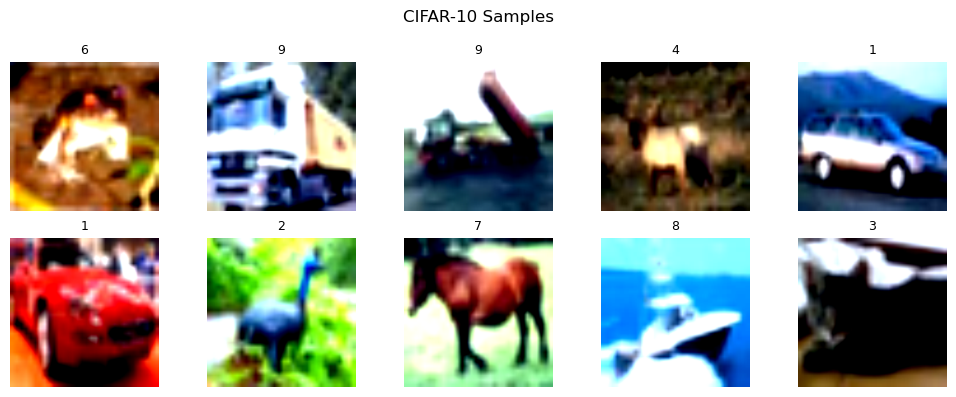

In [21]:
# code copied from lab 4, just for visualisation

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, label = CIFAR_train_data[i]
    img = img / 2 + 0.5
    ax.imshow(torch.permute(img, (1, 2, 0)))
    ax.set_title(label, fontsize=9)
    ax.axis('off')
plt.suptitle('CIFAR-10 Samples')
plt.tight_layout()
plt.show()

In [22]:
# Setting up data loaders
def get_data_loaders(batch_size=64, shuffle=True):
    training_dataloader = DataLoader(CIFAR_train_data, batch_size=batch_size, shuffle=shuffle)
    test_dataloader = DataLoader(CIFAR_test_data, batch_size=batch_size, shuffle=False)

    return training_dataloader, test_dataloader

**MobileNetV3**

In [23]:
# Setting up model

def get_mobile_net_model(in_features=224, out_features=10):

    # in_features is number of in features, need modification to our dataset 
    # out_features is number of out features (i.e., classes), need modifcation to our data

    mobilenet_v3_small = models.mobilenet_v3_small(weights = None)
    mobilenet_v3_small.classifier[3] = nn.Linear(in_features=mobilenet_v3_small.classifier[3].in_features, out_features=out_features)

    print(mobilenet_v3_small.classifier)

    return mobilenet_v3_small

In [24]:
# Setting up optimiser for model

# TODO: justify the use of AdamW over SGD?
def get_optimiser_for_model(model):
    return torch.optim.AdamW(params=model.parameters(),lr=1e-3, weight_decay=1e-2)

In [25]:
# The different loss functions

ce = loss.CrossEntropyLoss()
weighted_ce = loss.WeightedCrossEntropyLoss(class_weights=class_weights)
label_smoothing_ce = loss.LabelSmoothingCrossEntropyLoss(smoothing=0.1)
focal_loss = loss.FocalLoss(gamma=2.0, alpha=None)
class_balanced_loss = loss.ClassBalancedLoss(samples_per_class=samples_per_class, beta=0.9999)

# losses = {
#     "Cross-Entropy": ce(logits, targets),
#     "Weighted Cross-Entropy": weighted_ce(logits, targets),
#     "Label Smoothing CE": label_smoothing_ce(logits, targets),
#     "Focal Loss": focal_loss(logits, targets),
#     "Class-Balanced Loss": class_balanced_loss(logits, targets),
# }

# for name, value in losses.items():
#     print(f"{name}: {value.item():.4f}")

criterions = {
    "ce": ce,
    "weighted_ce": weighted_ce,
    "label_smoothing_ce": label_smoothing_ce,
    "focal_loss": focal_loss,
    "class_balanced_loss": class_balanced_loss
    }


/students/u7947738/Documents/comp3242/project/Testing-MobileNet/loss.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  class_weights = torch.tensor(class_weights, dtype=torch.float32)
/students/u7947738/Documents/comp3242/project/Testing-MobileNet/loss.py:142: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  samples_per_class = torch.tensor(samples_per_class, dtype=torch.float32)


**Training**

In [ ]:
# TBD. Add loss functions in their section or their own.
import loss
import util
import pandas as pd
from pathlib import Path
import importlib
from plotter import *

importlib.reload(loss)
save_dir = Path("training_results")
save_dir.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

training_loader,testing_loader = get_data_loaders()
steps = 3 # just testing with smaller values for now
batches_to_train_with = 3

# get the samples_per_class
samples_per_class = torch.zeros(no_train_classes, dtype=torch.long)
for batch in training_loader:
    # Common case: batch = (inputs, labels)
    _, labels = batch

    # If labels are one-hot encoded, convert to class indices
    if labels.ndim > 1:
        labels = labels.argmax(dim=1)

    counts = torch.bincount(labels.cpu(), minlength=no_train_classes)
    samples_per_class += counts
    
class_weights = samples_per_class
print(f"samples_per_class: {samples_per_class}")

all_training_losses = []
all_training_conf_matrices = []
all_testing_conf_matrices = []
all_accuracies = []

# Main training loop
for criterion_name, criterion in criterions.items():
    model = get_mobile_net_model().to(device)
    optimizer = get_optimiser_for_model(model)
    criterion = criterion.to(device)

    num_classes = no_train_classes

    for epoch in range(steps):
        model.train()
        epoch_training_loss = 0.0
        trained_batches = 0
        train_conf_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)
        for data,labels in training_loader:
            data = data.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(data)
            loss_value = criterion(outputs, labels)
            
            loss_value.backward()
            optimizer.step()

            epoch_training_loss += loss_value.item()
            trained_batches += 1

            train_conf_matrix = util.update_confusion_matrix(
                train_conf_matrix,
                outputs.detach().cpu(),
                labels.detach().cpu()
            )

            if trained_batches > batches_to_train_with:
                break
        avg_training_loss = epoch_training_loss / trained_batches

        test_conf_matrix = util.evaluate_model(
            model,
            testing_loader,
            num_classes,
            device
        )

        train_correct = train_conf_matrix.diag().sum().item()
        train_total = train_conf_matrix.sum().item()
        train_accuracy = train_correct / train_total if train_total > 0 else 0.0

        test_correct = test_conf_matrix.diag().sum().item()
        test_total = test_conf_matrix.sum().item()
        test_accuracy = test_correct / test_total if test_total > 0 else 0.0

        all_accuracies.append({
            "criterion": criterion_name,
            "epoch": epoch + 1,
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy
        })
        
        all_training_losses.append({
            "criterion": criterion_name,
            "epoch": epoch + 1,
            "training_loss": avg_training_loss
        })

        for true_class in range(num_classes):
            for predicted_class in range(num_classes):
                all_training_conf_matrices.append({
                    "criterion": criterion_name,
                    "epoch": epoch + 1,
                    "true_class": true_class,
                    "predicted_class": predicted_class,
                    "count": train_conf_matrix[true_class, predicted_class].item()
                })

                all_testing_conf_matrices.append({
                    "criterion": criterion_name,
                    "epoch": epoch + 1,
                    "true_class": true_class,
                    "predicted_class": predicted_class,
                    "count": test_conf_matrix[true_class, predicted_class].item()
                })

        print(
            f"Criterion: {criterion_name}, "
            f"Epoch: {epoch + 1}/{steps}, "
            f"Training loss: {avg_training_loss:.4f}"
        )

pd.DataFrame(all_training_losses).to_csv(
    save_dir / "training_losses.csv",
    index=False
)

pd.DataFrame(all_training_conf_matrices).to_csv(
    save_dir / "training_confusion_matrices.csv",
    index=False
)

pd.DataFrame(all_testing_conf_matrices).to_csv(
    save_dir / "testing_confusion_matrices.csv",
    index=False
)

pd.DataFrame(all_accuracies).to_csv(
    save_dir / "accuracies.csv",
    index=False
)

print("\nTraining complete.")
print(f"Results saved to: {save_dir.resolve()}")


samples_per_class: tensor([5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000])
Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=10, bias=True)
)
Criterion: ce, Epoch: 1/3, Training loss: 2.3519
Criterion: ce, Epoch: 2/3, Training loss: 2.2482
Criterion: ce, Epoch: 3/3, Training loss: 2.1548
Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=10, bias=True)
)
Criterion: weighted_ce, Epoch: 1/3, Training loss: 2.3433
Criterion: weighted_ce, Epoch: 2/3, Training loss: 2.3442
Criterion: weighted_ce, Epoch: 3/3, Training loss: 2.2241
Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=10, bias=True)
)
Criterion: label_smoo

FileNotFoundError: [Errno 2] No such file or directory: '/training_results/training_losses.csv'


Plotting results to /plots.
defaultdict(<class 'list'>, {'ce': [(1, 2.3519339561462402), (2, 2.2481539249420166), (3, 2.1548328399658203)], 'weighted_ce': [(1, 2.343294143676758), (2, 2.344240427017212), (3, 2.2241240739822388)], 'label_smoothing_ce': [(1, 2.3413795828819275), (2, 2.271640717983246), (3, 2.177320897579193)], 'focal_loss': [(1, 1.8476627469062805), (2, 1.8320291638374329), (3, 1.6990619897842407)], 'class_balanced_loss': [(1, 2.3328959345817566), (2, 2.2695459127426147), (3, 2.1945298314094543)]})


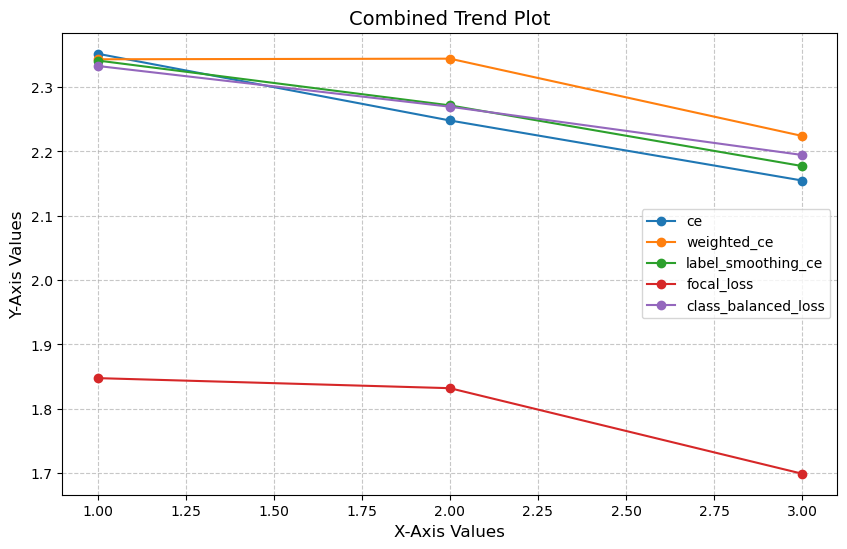

defaultdict(<class 'list'>, {'ce': [(1, 0.09765625), (2, 0.13671875), (3, 0.21875)], 'weighted_ce': [(1, 0.09375), (2, 0.12109375), (3, 0.171875)], 'label_smoothing_ce': [(1, 0.1484375), (2, 0.1640625), (3, 0.171875)], 'focal_loss': [(1, 0.15625), (2, 0.16015625), (3, 0.1796875)], 'class_balanced_loss': [(1, 0.1328125), (2, 0.15234375), (3, 0.171875)]})


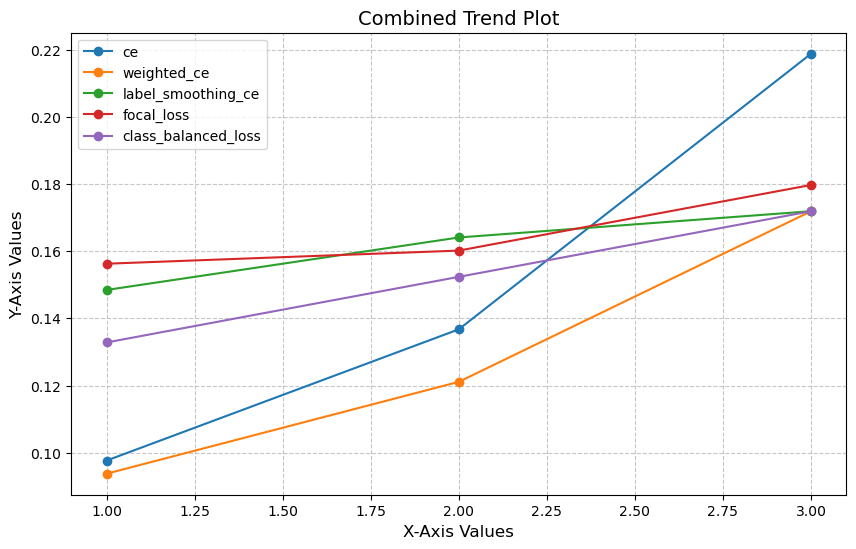

In [28]:
# Plotting

print("\nPlotting results to /plots.")
results_plotter("training_results/training_losses.csv", "training_losses")
results_plotter("training_results/accuracies.csv", "accuracies")

**Evaluation**

In [ ]:
eval_loss = 0.0
instances_to_test_with = 200
instances_tested = 0

model.eval()
criterion = ce

with torch.no_grad():
    for data, target in testing_loader:
        prediction = model(data)
        eval_loss += ce(prediction, target).item()
        instances_tested += 1

        if instances_tested > instances_to_test_with:
            break

print(eval_loss)


RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

**Misc.**